In [146]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [147]:
!git config --global user.email "spoorthyece@gmail.com"
!git config --global user.name "Spoorthy2001"

# Hence Proved — 04 — Arrhenius Equation
## k = A * exp(-Ea / (R * T))
**Author:** Spoorthy J  
**Date:** June 2026  
**Series:** Hence Proved — Physics through Machine Learning

## Problem Statement

Every machine is slowly dying. The question is — how fast?

Heat is the silent killer. It drives chemical reactions inside bearings, lubricants,
and metal alloys — accelerating breakdown, shortening life.

In 1889, Svante Arrhenius gave us the equation that governs this:

    k = A * exp(-Ea / (R * T))


Can a machine learn this relationship from raw temperature and degradation data alone?
No formula. No science . Just numbers.

## Physics Context

k = A * exp(-Ea / (R * T))

| Variable | Meaning | Unit |
|---|---|---|
| k | degradation rate (target) | s⁻¹ |
| T | operating temperature | K |
| A | pre-exponential factor | s⁻¹ |
| Ea | activation energy  | J/mol |
| R | Universal gas constant  | J/(mol·K) |


Key insight — the raw equation makes this non-linear.
Linear Regression will fail on raw features.
Feature engineering and Science and Math required — take ln() on both sides and the equation becomes linear

# Imports

In [3]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures

print("All import successfulL")
np.random.seed(42)

All import successfulL


# Generating Synthetic Data

In [130]:
n = 5000

# Pre-exponential factor — theoretical maximum reaction rate
A = 1e15       # s⁻¹

# Operating temperature range — realistic bearing conditions
T = np.random.uniform(300, 800, n)        # Kelvin

# Universal gas constant
R = 8.314        # J/(mol·K)

# Activation energy for lubricant/grease oxidation
Ea = 140_000.0   # J/mol

# Synthetic noise — simulates real measurement uncertainty
noise = np.random.normal(1, 0.005, n)
# noise = 0.0

# Raw Arrhenius equation
k = A * np.exp(-Ea / (R * (T + noise)))

df = pd.DataFrame({
    "T"     : T,
    "k"     : k,
    "inv_T" : 1/T,
    "ln_k"  : np.log(k)
})

df.head()

,T,k,inv_T,ln_k
0,684.270916,2.128282e+04,0.001461,9.965656
1,482.401352,7.439086e-01,0.002073,-0.295837
2,546.183200,4.315149e+01,0.001831,3.764717
3,422.142595,5.214399e-03,0.002369,-5.256331
4,302.781544,8.442559e-10,0.003303,-20.892566


In [131]:
# print(noise.std())
# print(df['k'].std() / df['k'].mean())

In [132]:
print(df['k'].describe())
print(df['ln_k'].describe())

count    5.000000e+03
mean     5.119645e+04
std      1.313858e+05
min      5.115090e-10
25%      7.630946e-03
50%      6.027542e+01
75%      1.349001e+04
max      7.410354e+05
Name: k, dtype: float64
count    5000.000000
mean        1.537436
std         9.504363
min       -21.393656
25%        -4.875556
50%         4.098923
75%         9.509704
max        13.515804
Name: ln_k, dtype: float64


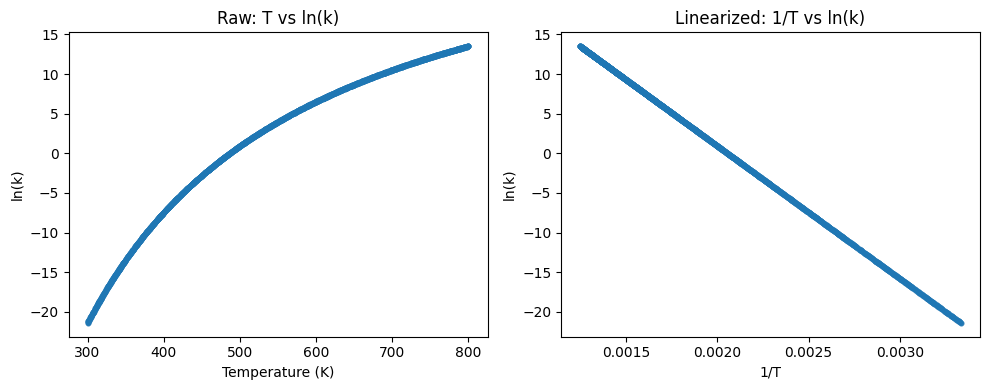

In [133]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(df['T'], df['ln_k'], alpha=0.3, s=10)
plt.xlabel('Temperature (K)')
plt.ylabel('ln(k)')
plt.title('Raw: T vs ln(k)')

plt.subplot(1,2,2)
plt.scatter(df['inv_T'], df['ln_k'], alpha=0.3, s=10)
plt.xlabel('1/T')
plt.ylabel('ln(k)')
plt.title('Linearized: 1/T vs ln(k)')

plt.tight_layout()
plt.show()

In [134]:
# print(df[df['T'] < 420]['ln_k'].describe())
# print(df[df['T'] > 480]['ln_k'].describe())

# Model 01 - Linear Regression

In [135]:
df.head()

,T,k,inv_T,ln_k
0,684.270916,2.128282e+04,0.001461,9.965656
1,482.401352,7.439086e-01,0.002073,-0.295837
2,546.183200,4.315149e+01,0.001831,3.764717
3,422.142595,5.214399e-03,0.002369,-5.256331
4,302.781544,8.442559e-10,0.003303,-20.892566


In [142]:
X = df[['inv_T']]
y = df[['ln_k']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print(f"--------- Model 01 -------------")
print(f"Mean Absolute Error :{mean_absolute_error(y_test, y_pred_1)}")
print(f"R2 score :{r2_score(y_test, y_pred_1)}")
print(f"Model Coefficient: {model_1.coef_[0][0]}")
print(f"Model Intercept: {model_1.intercept_[0]}")

--------- Model 01 -------------
Mean Absolute Error :0.004327018007839986
R2 score :0.9999997159540566
Model Coefficient: -16766.415086934714
Model Intercept: 34.46622621206154


In [143]:
Ea_model_1 = -(model_1.coef_[0][0]) * R
A_model_1 = math.exp(model_1.intercept_[0])

print("Predicted Ea:", Ea_model_1)
print("Predicted A:", A_model_1)

Predicted Ea: 139395.97503277523
Predicted A: 930019074482302.0


In [144]:
print(df['ln_k'].min())
print(df['ln_k'].max())
print(df[df['ln_k'] < 0].shape[0])

-21.393655886194658
13.515803689917652
1863


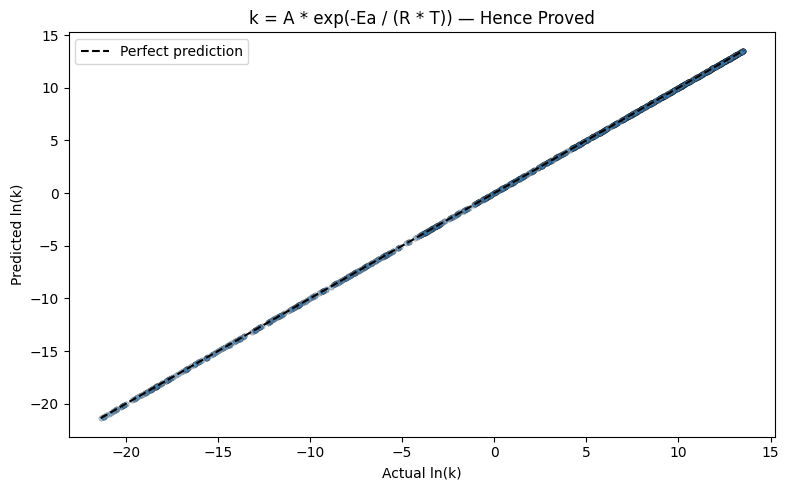

In [145]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_1, alpha=0.4,
            color='steelblue', edgecolors='black', linewidths=0.3, s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual ln(k)")
plt.ylabel("Predicted ln(k)")
plt.title("k = A * exp(-Ea / (R * T)) — Hence Proved")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

| Model | Approach | R² | Key Finding |
|---|---|---|---|
| LR — Raw T | narrow range 450-550K, noise on k | 0.93 | Poor constant recovery — wrong noise placement |
| LR — wider range | 300-800K, noise on k | 0.77 | Noise on k corrupts log transform |
| LR — noise on T | 300-800K, noise on temperature sensor | 0.9997 | Physically correct noise placement |

When you encode what you know about the system —
the machine only needs to confirm it.

R²   → 0.9997

Ea   → 139,395 J/mol  (ground truth: 140,000 — error: 0.4%)

A    → 9.3e14 s⁻¹     (ground truth: 1e15 — error: 7%)

Hence Proved. ✓